In [1]:
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

from SSA2 import SSAv3


%matplotlib inline

In [2]:
data105 = pd.read_csv('105v2.csv', parse_dates=True, index_col='DateTime',encoding="windows-1252") # или 106.csv
data105.head(5)

,AffinityIndex,SerialNumber,H,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,,,,
2017-07-22 00:01:00,6,12427AMK-03,15,15.86,0.20,94.53,0.01,0.44,-0.13,750.45,100.0,15.86,17.99,14.53,1.1954,342.12
2017-07-22 00:02:00,6,12427AMK-03,15,15.88,0.28,104.28,0.15,0.53,-0.19,750.45,100.0,15.88,18.01,14.55,1.1953,342.14
2017-07-22 00:03:00,6,12427AMK-03,15,15.87,0.23,68.53,0.11,0.36,-0.19,750.45,100.0,15.87,17.99,14.54,1.1954,342.13
2017-07-22 00:04:00,6,12427AMK-03,15,15.95,0.17,47.04,0.01,0.33,-0.18,750.45,100.0,15.95,18.09,14.62,1.1950,342.18
2017-07-22 00:05:00,6,12427AMK-03,15,16.01,0.06,11.99,0.01,0.22,-0.19,750.45,100.0,16.01,18.16,14.68,1.1947,342.22


In [3]:
del data105['AffinityIndex'] 
del data105['SerialNumber'] 
del data105['H'] 
del data105['WminH'] 
del data105['WmaxH'] 
del data105['WindDirectionH(Â°)'] 
del data105['TdewPoint(Â°C)'] 
del data105['WaterVaporElasticity'] 
del data105['AbsolutusHumidity'] 
del data105['DensityofAir'] 
del data105['SpeedofSoundinAir'] 

In [4]:
# Выбор периода с выбранной частотой
# 1=1min 2=2min, 10=10min, 60=1hour, 720=12hour, 1440=1day, 10080=1week, 44640=1month

# 2019-04-09 01:01:00':'2020-04-04 01:01:00
from IPython.display import display

period2=data105['2017-07-22 00:01:00':'2020-04-04 01:01:00'][::1]
per_temp2 = period2['Tmean']  #24     48

display(per_temp2.head(5))
display(per_temp2.tail(5))

DateTime
2017-07-22 00:01:00    15.86
2017-07-22 00:02:00    15.88
2017-07-22 00:03:00    15.87
2017-07-22 00:04:00    15.95
2017-07-22 00:05:00    16.01
Name: Tmean, dtype: float64

DateTime
2020-04-04 00:57:00   -2.72
2020-04-04 00:58:00   -2.70
2020-04-04 00:59:00   -2.54
2020-04-04 01:00:00   -2.68
2020-04-04 01:01:00   -2.46
Name: Tmean, dtype: float64

In [5]:
desc = per_temp2.describe()
desc.loc['count'] = desc.loc['count'].astype(int).astype(str)
print(desc)

count    1178369
mean      2.0411
std      14.0494
min       -41.18
25%        -7.02
50%          2.8
75%        13.47
max         31.9
Name: Tmean, dtype: object


C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


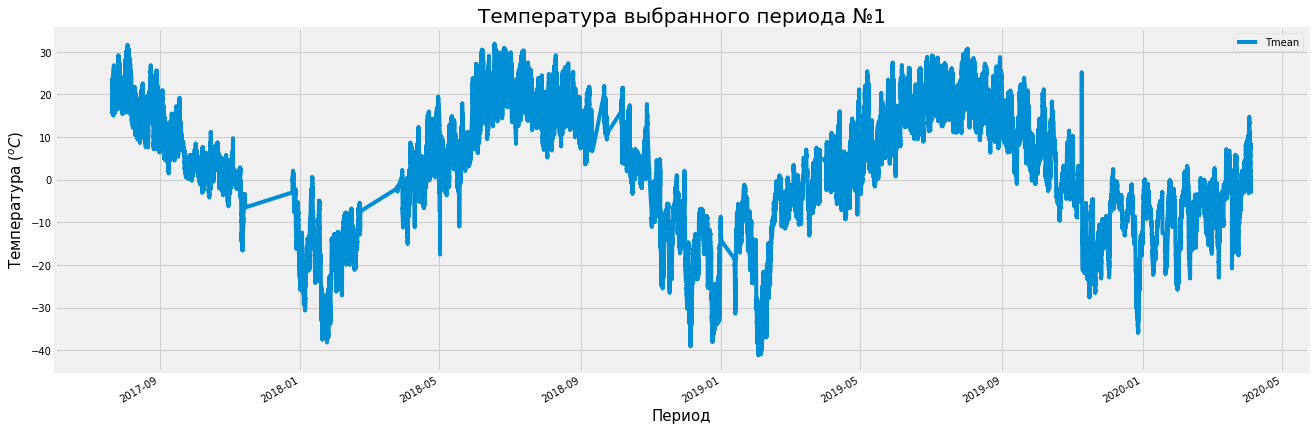

In [6]:
plt.figure()
per_temp2.plot(figsize=[20,7])
#per_temp2.plot(style='k.')
plt.title('Температура выбранного периода №1', fontsize=20)
plt.grid(True)
plt.ylabel('Температура ($^oC$)',fontsize=15)
plt.xlabel('Период',fontsize=15)
plt.legend()

In [7]:
#pd.set_option('display.max_rows', 500)

per_temp105 = data105['Tmean']  #24     48 ТЕМПЕРАТУРА

per_temp105

DateTime
2017-07-22 00:01:00    15.86
2017-07-22 00:02:00    15.88
2017-07-22 00:03:00    15.87
2017-07-22 00:04:00    15.95
2017-07-22 00:05:00    16.01
                       ...  
2020-04-09 23:55:00     0.46
2020-04-09 23:56:00     0.50
2020-04-09 23:57:00     0.58
2020-04-09 23:58:00     0.48
2020-04-09 23:59:00     0.49
Name: Tmean, Length: 1186390, dtype: float64

In [8]:
means105 = data105.groupby(pd.Grouper(freq='D')).mean()  # ПЕРИОД
means105

,Tmean,WmeanH,WmeanV,AtmosphericPressure,RelativeHumidity
DateTime,,,,,
2017-07-22,19.476312,1.202660,-0.122234,750.230475,77.639915
2017-07-23,20.851142,1.164227,0.055816,749.047753,68.623974
2017-07-24,20.588375,1.556807,0.220068,746.373318,77.926284
2017-07-25,21.122393,2.011374,0.133744,742.115037,77.207245
2017-07-26,21.097521,1.113449,-0.164357,744.684319,80.063233
...,...,...,...,...,...
2020-04-05,5.206268,2.944479,1.023910,761.228300,28.456948
2020-04-06,6.587525,1.797609,0.383534,752.998987,41.198309
2020-04-07,7.605675,2.314117,0.821881,752.539291,52.011658


In [9]:
#pd.set_option('display.max_rows', 500)

per_temp105 = means105['Tmean']  #24     48 ТЕМПЕРАТУРА

per_temp105

DateTime
2017-07-22    19.476312
2017-07-23    20.851142
2017-07-24    20.588375
2017-07-25    21.122393
2017-07-26    21.097521
                ...    
2020-04-05     5.206268
2020-04-06     6.587525
2020-04-07     7.605675
2020-04-08     3.743463
2020-04-09     2.579199
Freq: D, Name: Tmean, Length: 993, dtype: float64

In [10]:
per_temp105.interpolate(method='linear', inplace=True)


In [11]:
# Using plotly.express
import plotly.express as px

import pandas as pd

fig = px.line(per_temp105, title='Температура выбранного периода ст. 105')
fig.show()

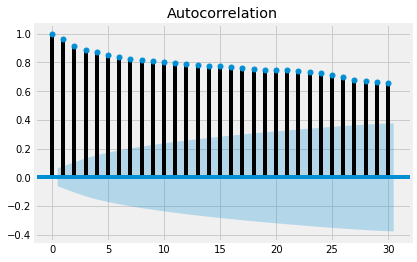

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(per_temp105)
plt.show()

<Figure size 432x288 with 0 Axes>

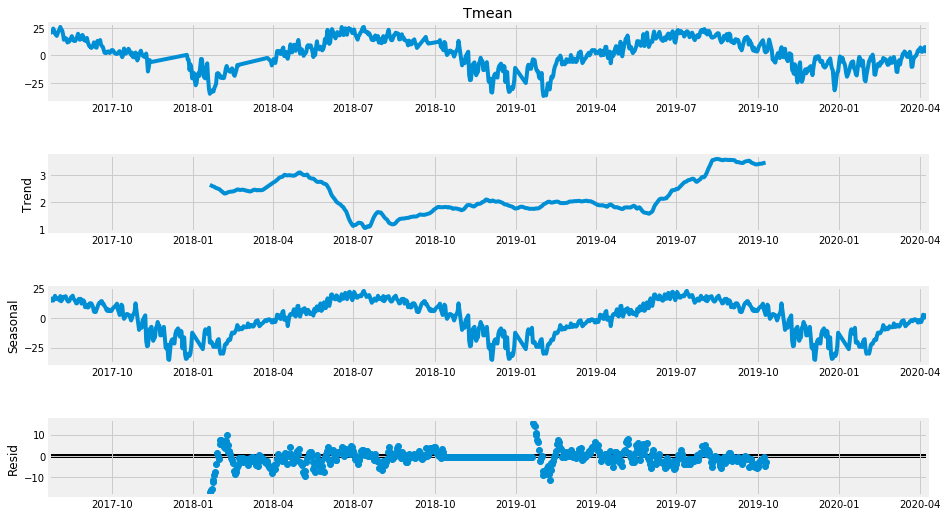

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(per_temp105, period=365)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

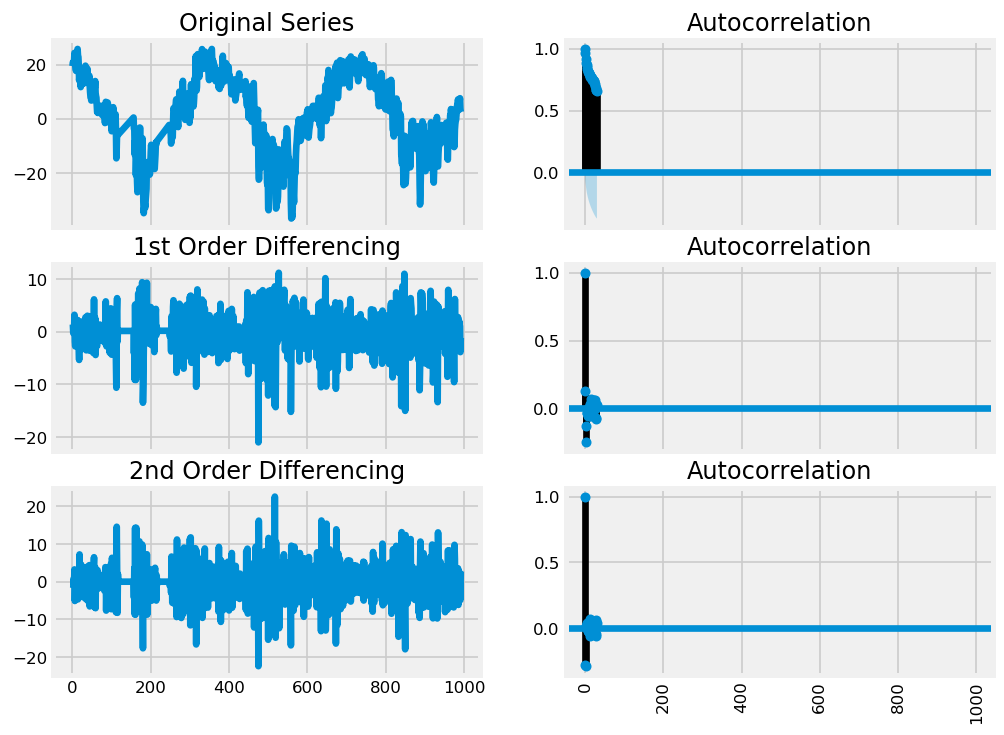

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Original Series
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(per_temp105.values); 
axes[0, 0].set_title('Original Series')
plot_acf(per_temp105.values, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(per_temp105.diff().values); 
axes[1, 0].set_title('1st Order Differencing')
plot_acf(per_temp105.diff().dropna().values,ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(per_temp105.diff().diff().values); 
axes[2, 0].set_title('2nd Order Differencing')
plot_acf(per_temp105.diff().diff().dropna().values,ax=axes[2, 1])

plt.xticks(rotation='vertical')
plt.show()

In [15]:
ssa = SSAv3(per_temp105) #
[x for x in dir(ssa) if '__' not in x and x[0]!='_']

['SVD',
 'diagonal_averaging',
 'embed',
 'forecast_recurrent',
 'freq',
 'getcontributions',
 'ts',
 'ts_N',
 'ts_name',
 'ts_v',
 'view_reconstruction',
 'view_s_contributions',
 'view_time_series']

In [16]:
K = 40 #+ матрица
seasonality = 12 # подозреваемая сезонность (12) 4 особо не влияет

In [17]:
ssa.embed(embedding_dimension=365, frequency=seasonality, verbose=True) # ИЗМЕНИТЬ ОБЯЗ 120 /40 стандартное
#         размер вложения         подозреваемая частота=подозреваемая сезонность


In [18]:
ssa.SVD(verbose=True)


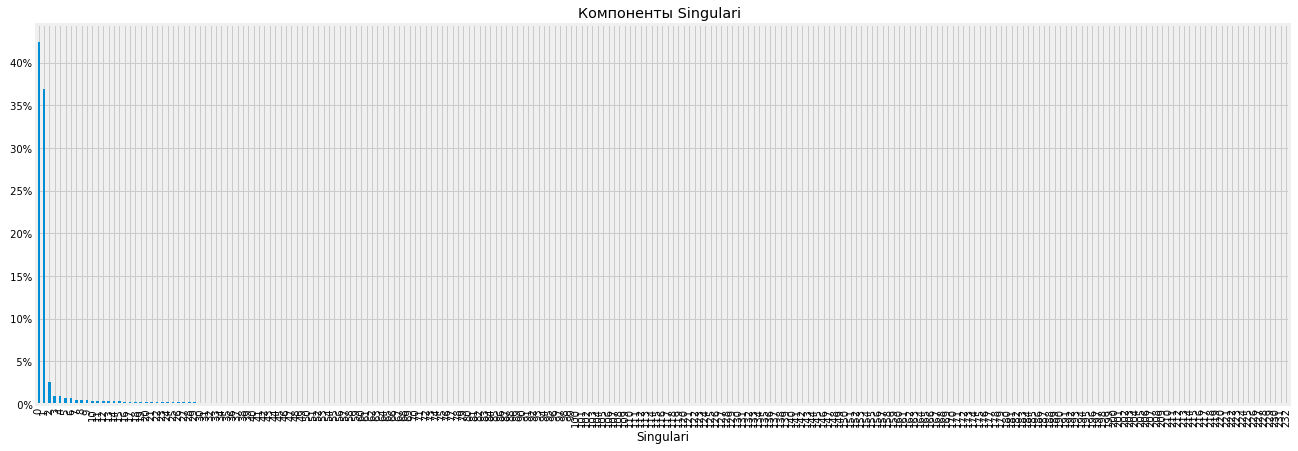

In [19]:
%matplotlib inline 
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20, 7 

ssa.view_s_contributions()


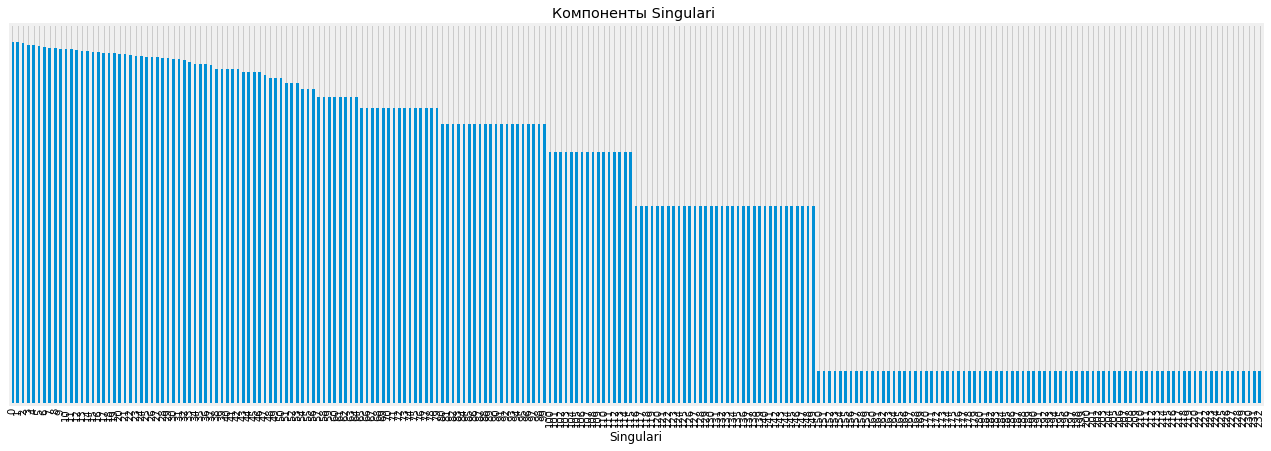

In [20]:
ssa.view_s_contributions(adjust_scale=True)


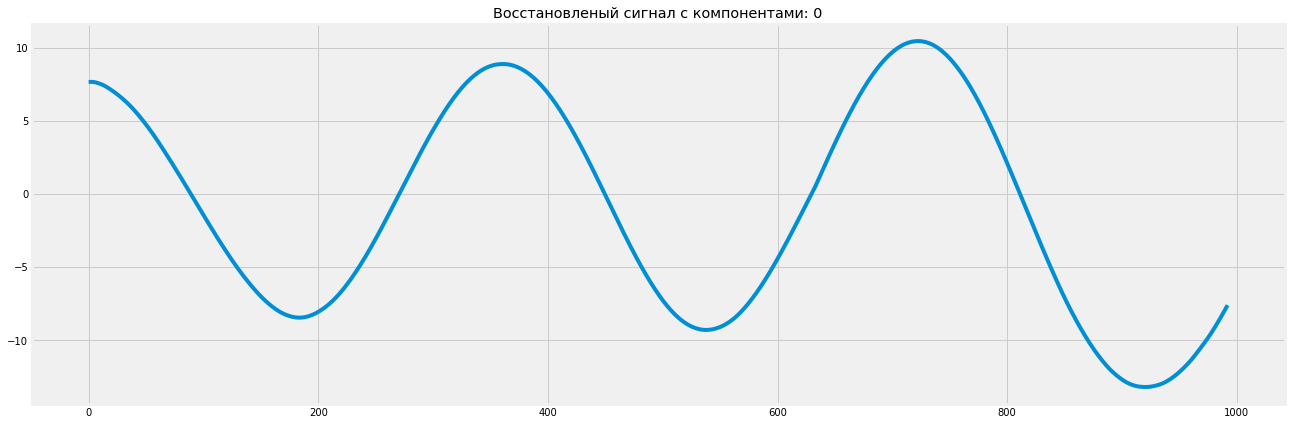

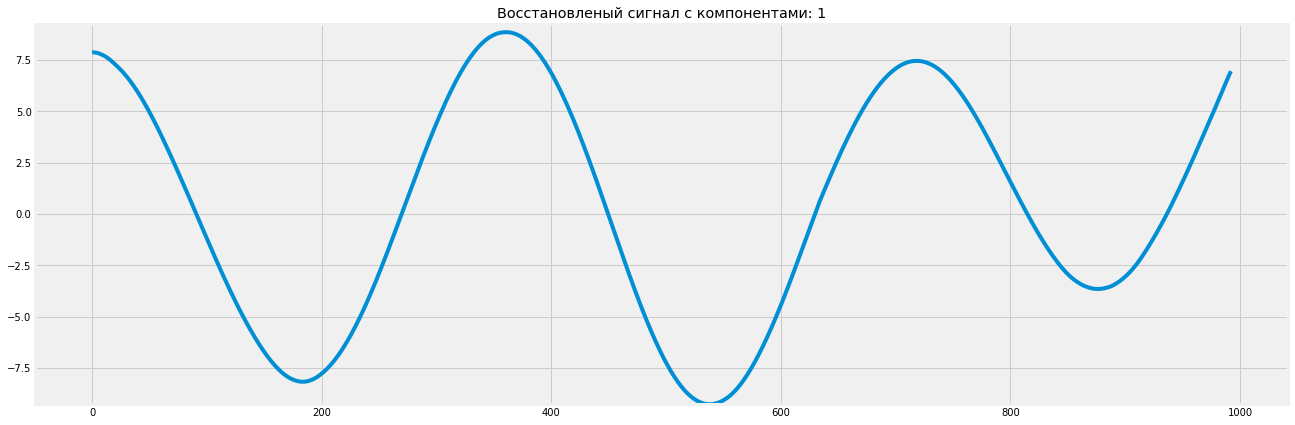

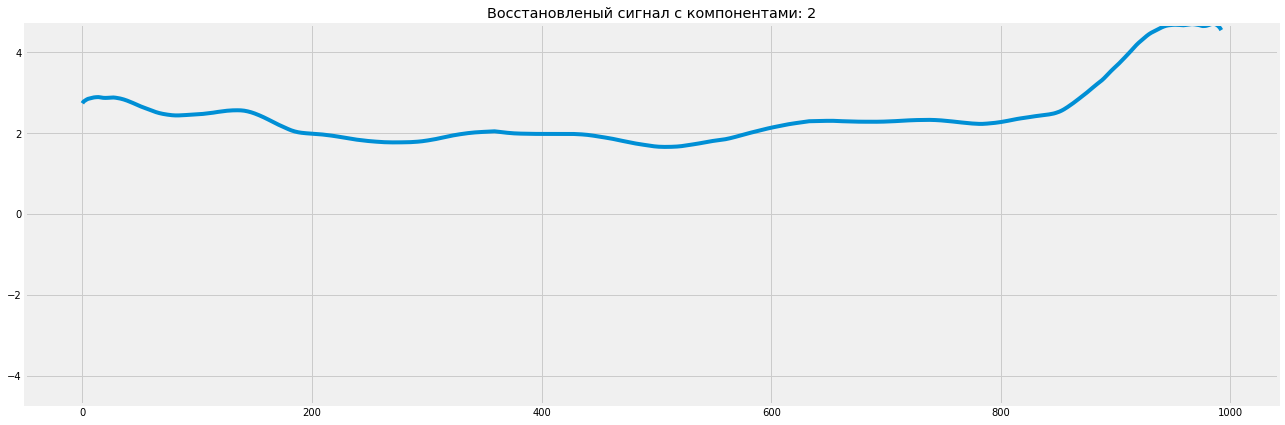

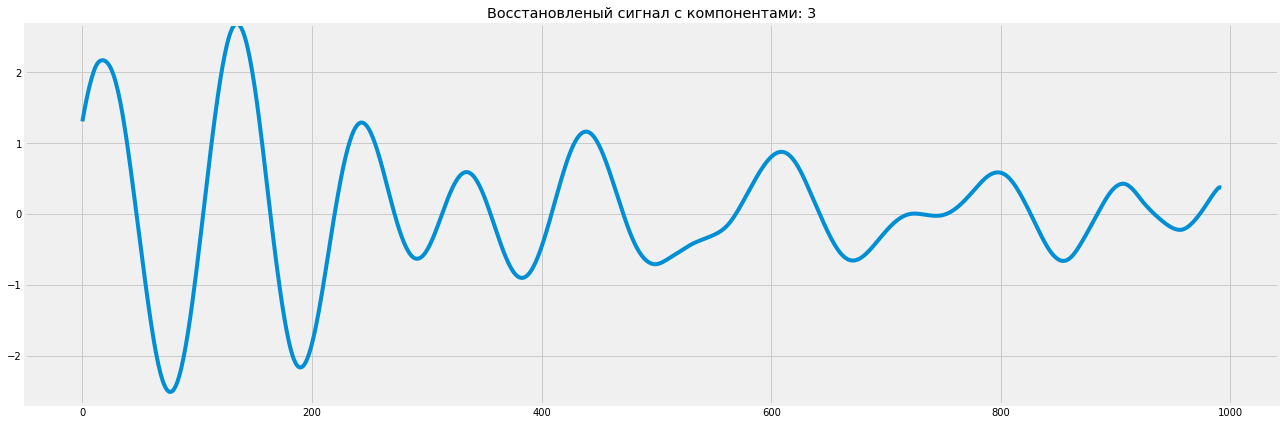

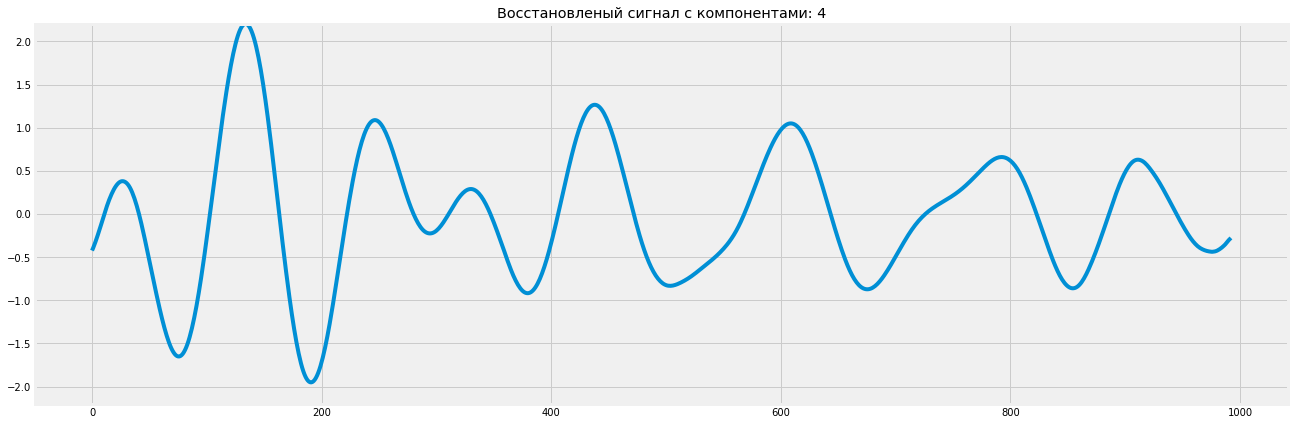

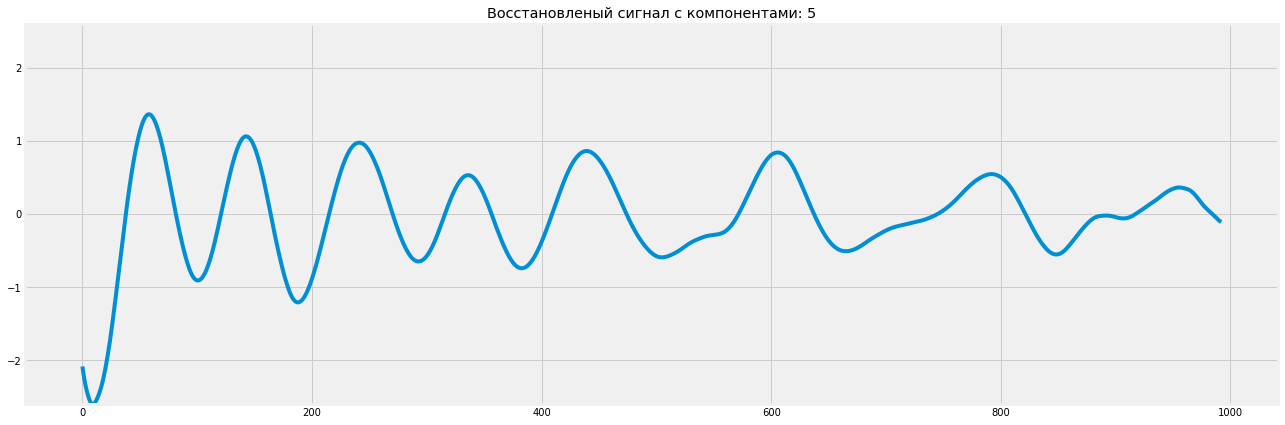

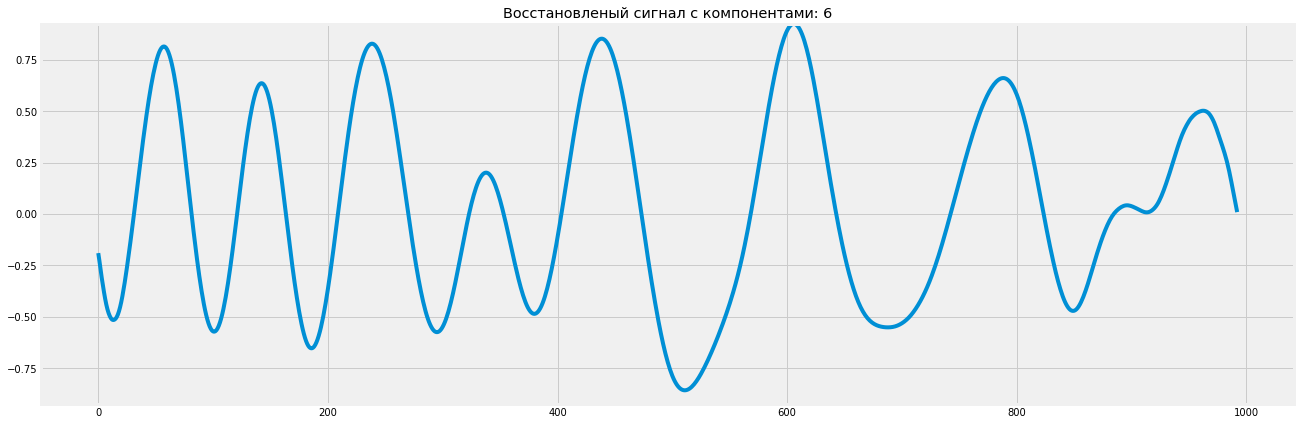

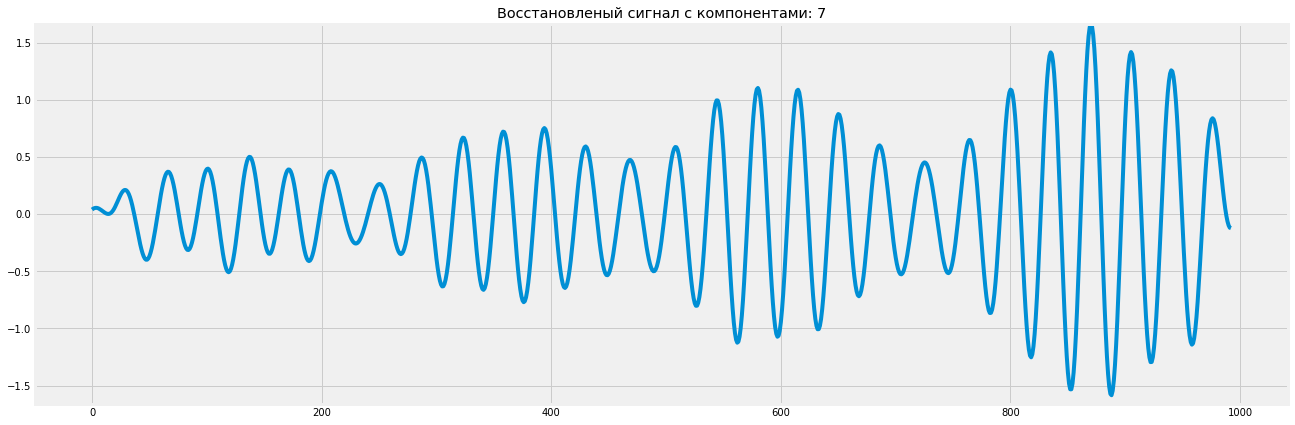

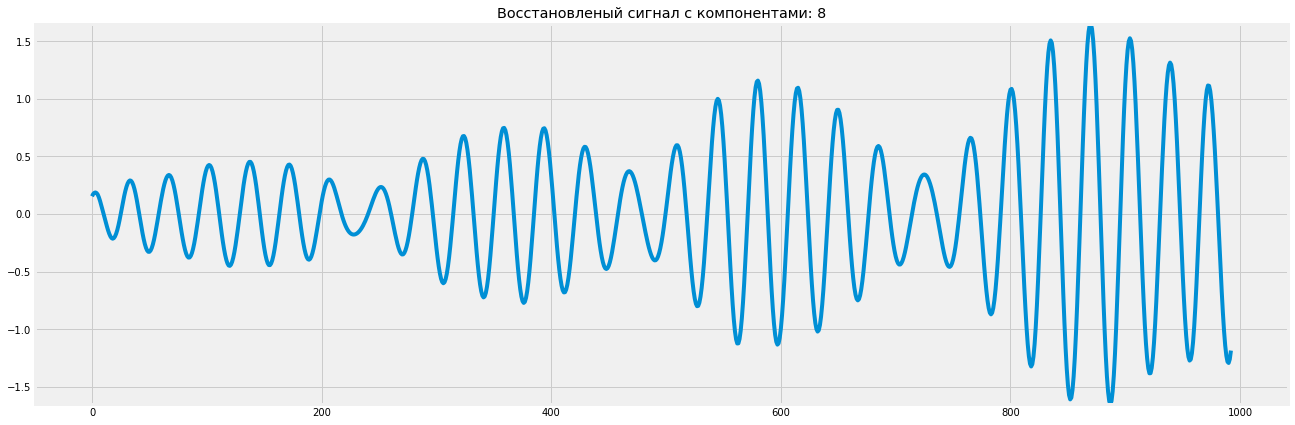

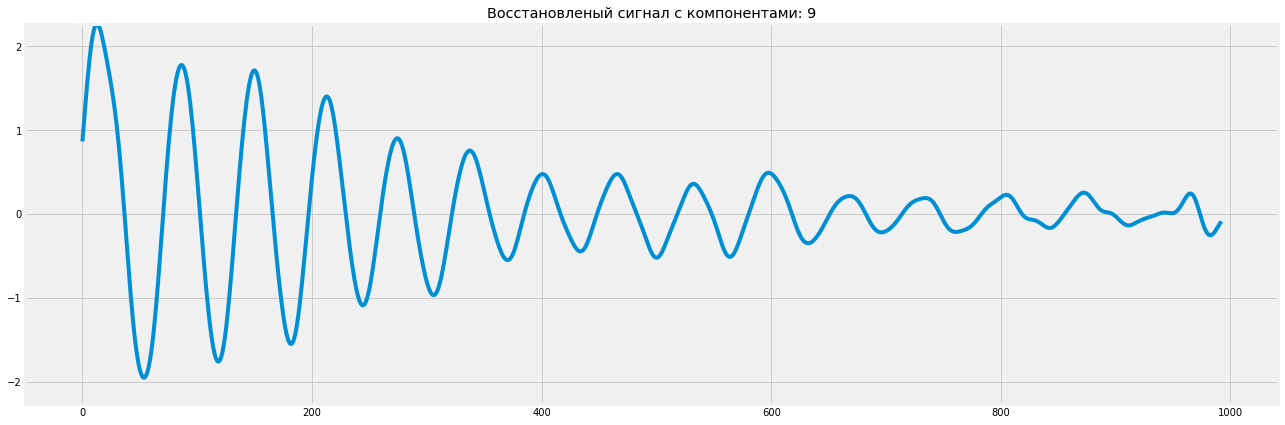

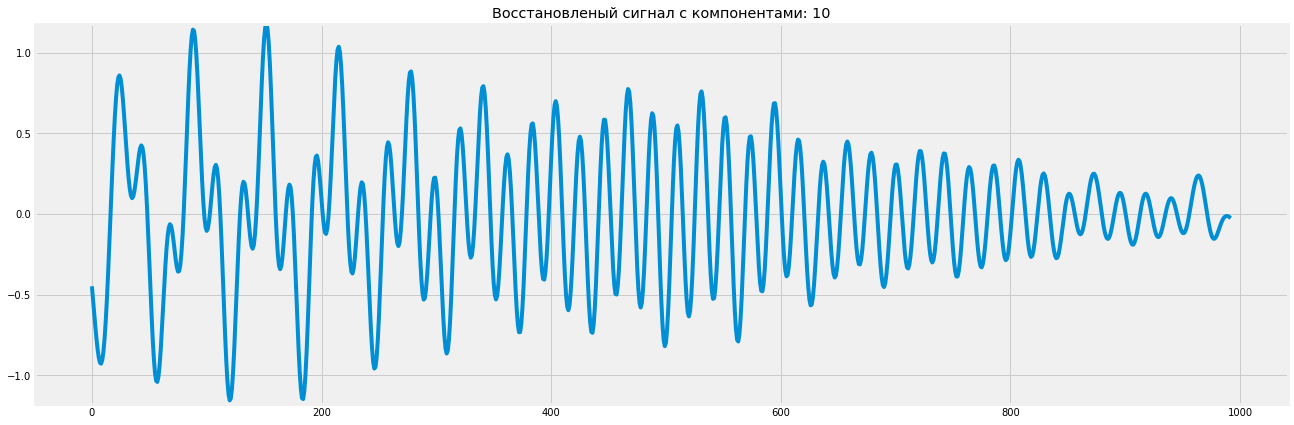

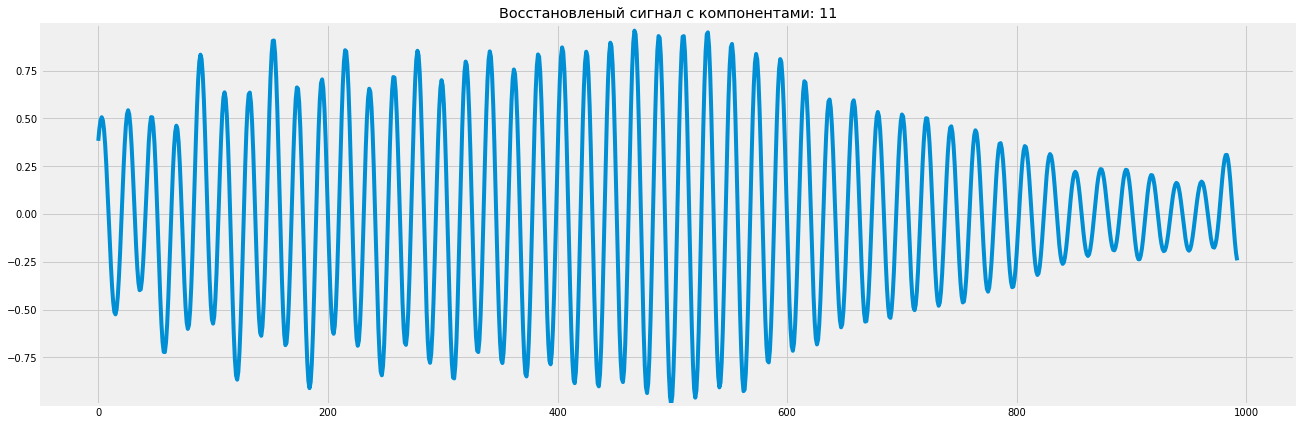

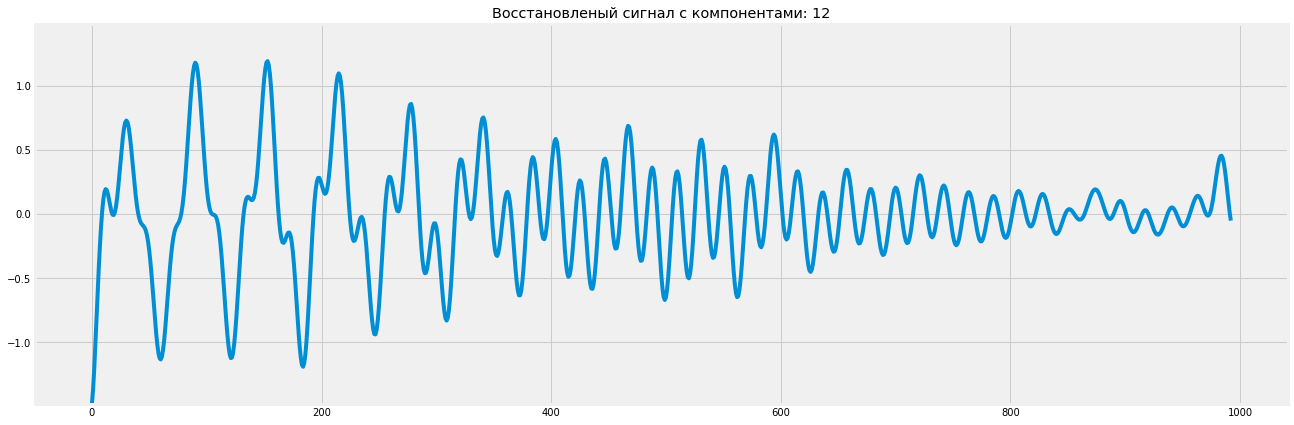

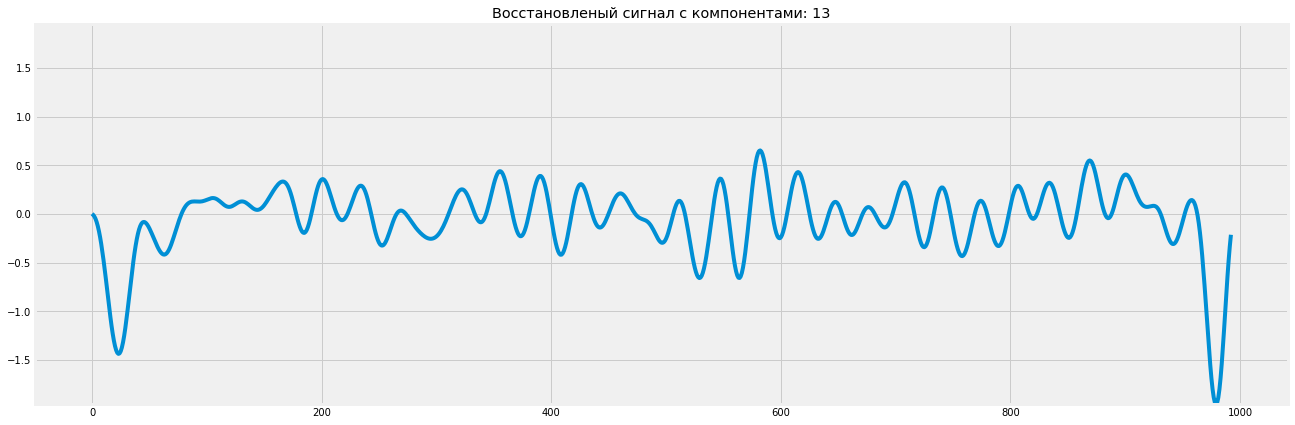

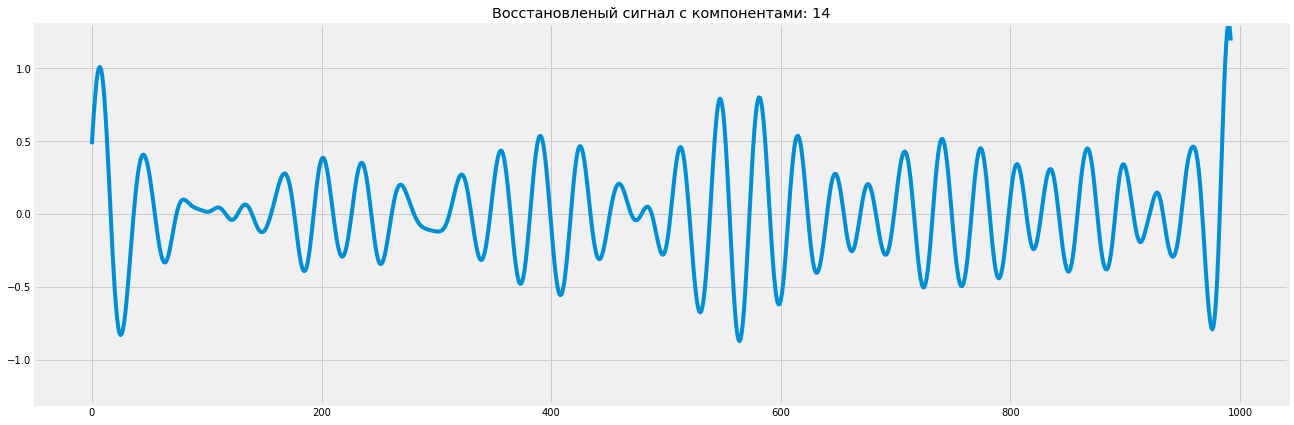

In [21]:
for i in range(15): # количество компонентов \ ИЗМЕНЯЕТСЯ ВОЗМОЖНЫ ОШИБКИ
    ssa.view_reconstruction(ssa.Xs[i], names=i, symmetric_plots=i!=0)
# Можно скрыть


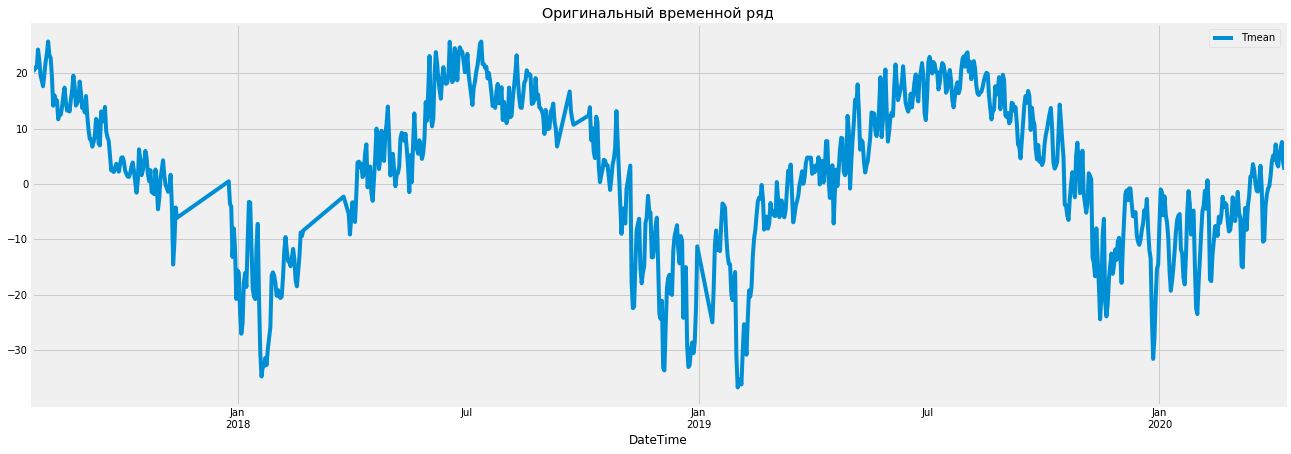

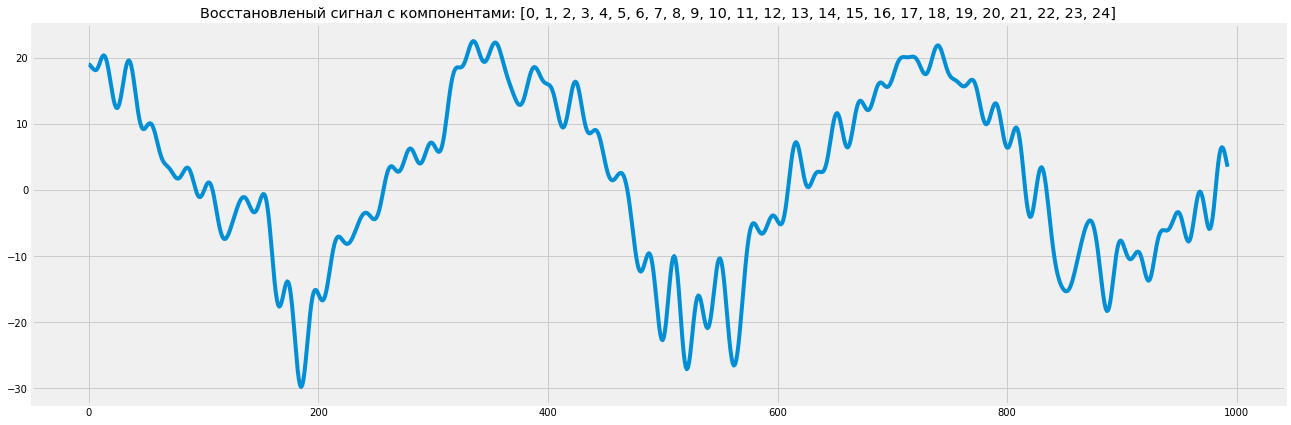

In [22]:
ssa.ts.plot(title='Оригинальный временной ряд'); # оригинальный график для сравнения
streams1 = [i for i in range(25)] # количество компонентов.
reconstructed1 = ssa.view_reconstruction(*[ssa.Xs[i] for i in streams1], names=streams1, return_df=True)


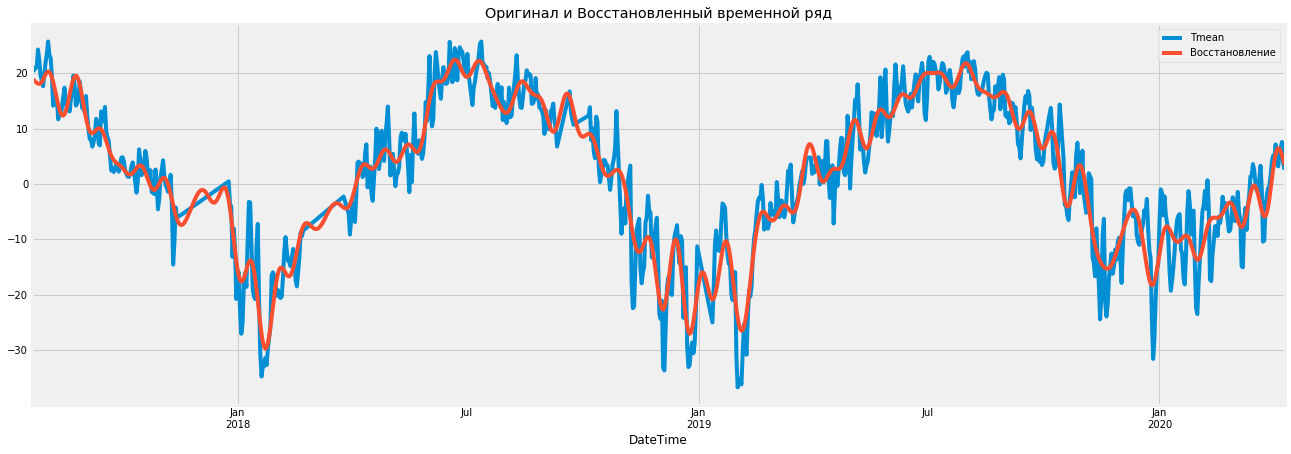

In [23]:
ts_copy1 = ssa.ts.copy()
ts_copy1['Восстановление'] = reconstructed1.Reconstruction.values
ts_copy1.plot(title='Оригинал и Восстановленный временной ряд');


,Tmean,Восстановление
DateTime,,
2017-07-22,19.476312,18.835275
2017-07-23,20.851142,19.273007
2017-07-24,20.588375,19.436259
2017-07-25,21.122393,19.467649
2017-07-26,21.097521,19.435783
...,...,...
2020-04-05,5.206268,7.342984
2020-04-06,6.587525,6.165648
2020-04-07,7.605675,4.396130


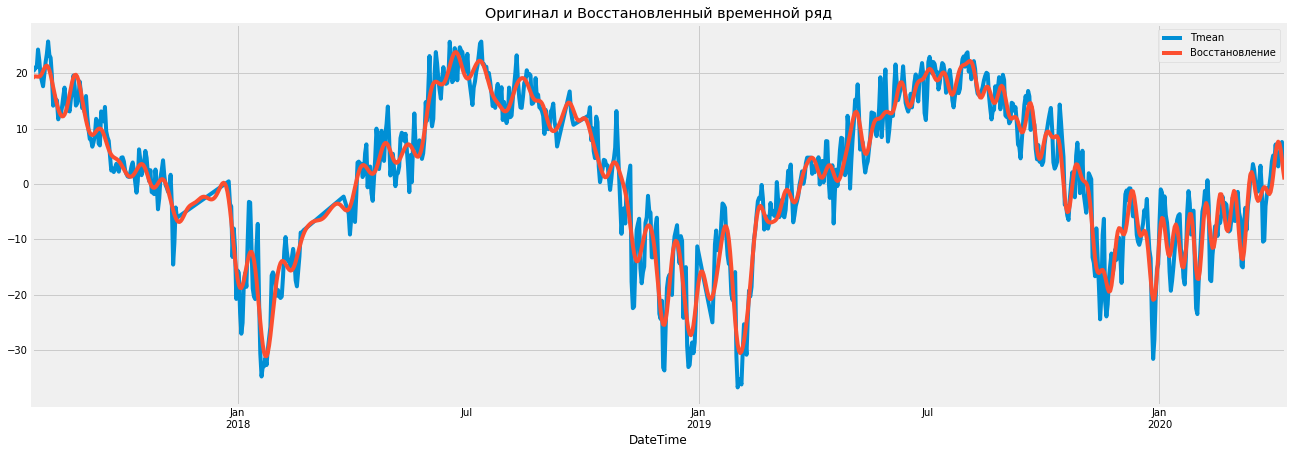

In [24]:
streams2 = [i for i in range(35)] # 10 стандарт. При выборке в 60 ставится 18. Количество выбранных значений для реконструкции
reconstructed2 = ssa.view_reconstruction(*[ssa.Xs[i] for i in streams2], 
                                          names=streams2, return_df=True, plot=False)
ts_copy2 = ssa.ts.copy()
ts_copy2['Восстановление'] = reconstructed2.Reconstruction.values
ts_copy2.plot(title='Оригинал и Восстановленный временной ряд');
ts_copy2

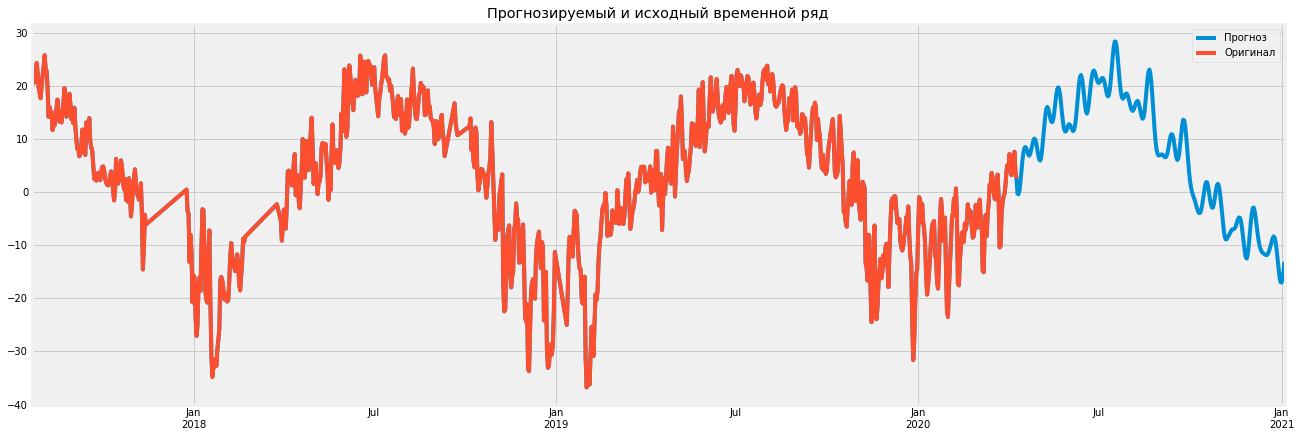

In [25]:
ssa.forecast_recurrent(steps_ahead=270, singular_values=streams2, plot=True) #48 количество прогнозируемых значений (60 дней))


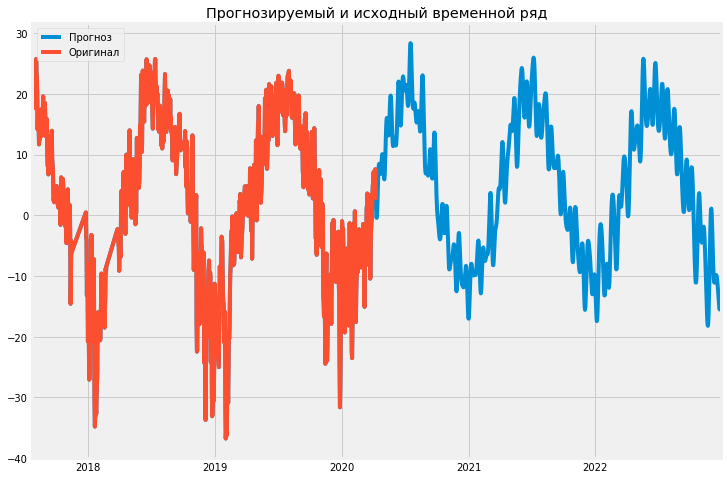

In [26]:
rcParams['figure.figsize'] = 11,8
ssa.forecast_recurrent(steps_ahead=ssa.ts.shape[0], singular_values=streams2, plot=True)
rcParams['figure.figsize'] = 11, 8